In [167]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
import numpy as np
import seaborn as sns

In [168]:
titanic = pd.read_csv("Titanic-Dataset.csv")

In [169]:
titanic

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [170]:
titanic.shape

(891, 12)

In [171]:
titanic.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [172]:
df = titanic.copy()

In [173]:
df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1, inplace=True)

In [174]:
df['Age'] = df['Age'].fillna(df['Age'].median())

In [175]:
df['Embarked'] = df['Embarked'].fillna('S')

In [176]:
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

In [177]:
df['Embarked'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

In [178]:
df.isnull().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

In [179]:
df.head(10)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,0,22.0,1,0,7.2500,0
1,1,1,1,38.0,1,0,71.2833,1
2,1,3,1,26.0,0,0,7.9250,0
3,1,1,1,35.0,1,0,53.1000,0
4,0,3,0,35.0,0,0,8.0500,0
5,0,3,0,28.0,0,0,8.4583,2
6,0,1,0,54.0,0,0,51.8625,0
7,0,3,0,2.0,3,1,21.0750,0
8,1,3,1,27.0,0,2,11.1333,0
9,1,2,1,14.0,1,0,30.0708,1


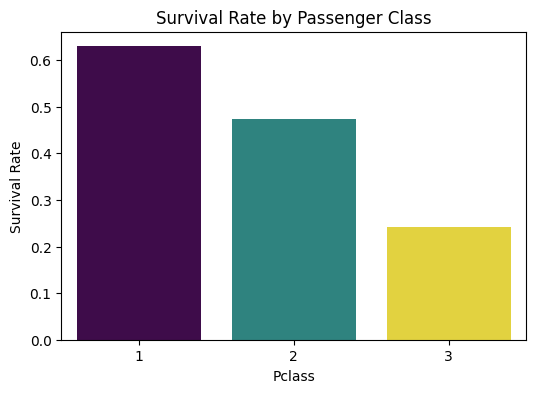

In [180]:
plt.figure(figsize=(6,4))
sns.barplot(x='Pclass', y='Survived', data=df, hue='Pclass', errorbar=None, palette='viridis', legend=False)
plt.title('Survival Rate by Passenger Class')
plt.ylabel('Survival Rate')
plt.show()

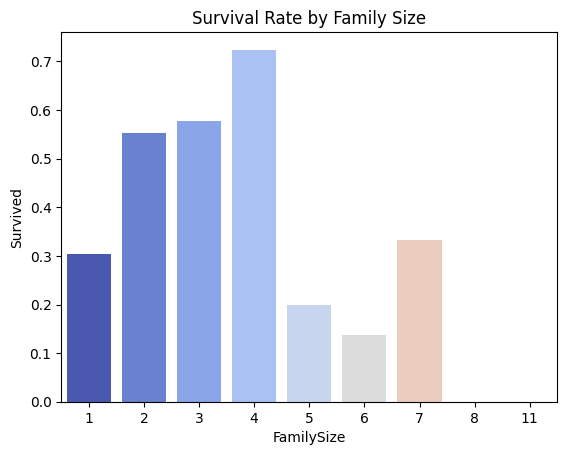

In [181]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
sns.barplot(x='FamilySize', y='Survived', data=df, hue='FamilySize', errorbar=None, palette='coolwarm', legend=False)
plt.title('Survival Rate by Family Size')
plt.show()

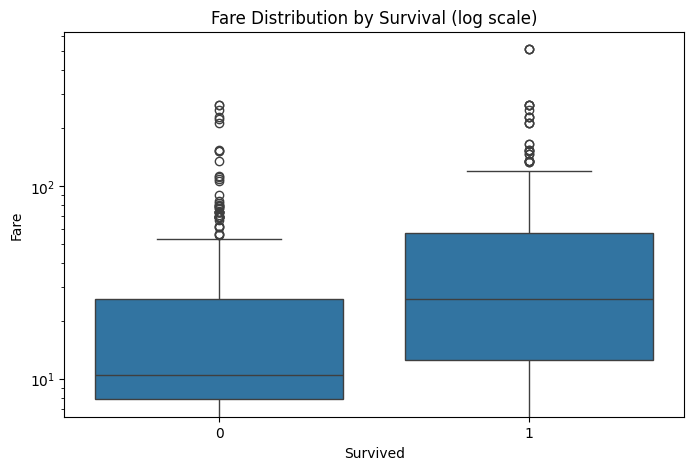

In [182]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Survived', y='Fare', data=df)
plt.yscale('log')  
plt.title('Fare Distribution by Survival (log scale)')
plt.show()

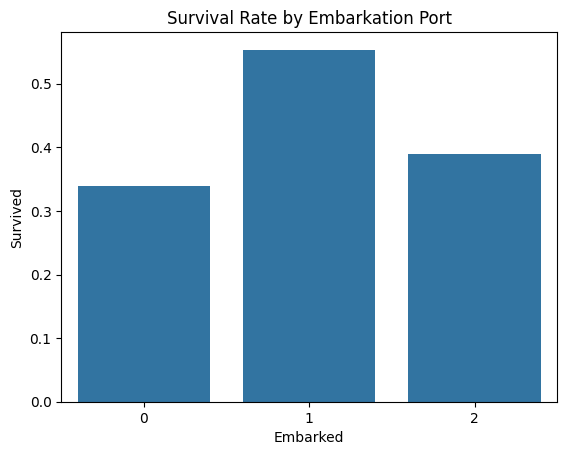

In [183]:
sns.barplot(x='Embarked', y='Survived', data=df, errorbar=None)
plt.title('Survival Rate by Embarkation Port')
plt.show()

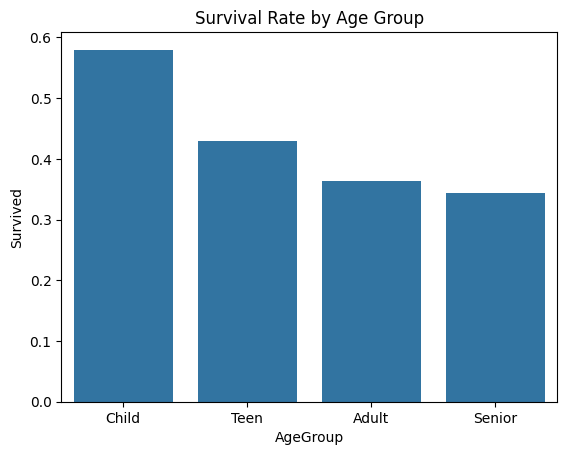

In [184]:
bins = [0, 12, 18, 50, 80]
labels = ['Child', 'Teen', 'Adult', 'Senior']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)
sns.barplot(x='AgeGroup', y='Survived', data=df, errorbar=None)
plt.title('Survival Rate by Age Group')
plt.show()

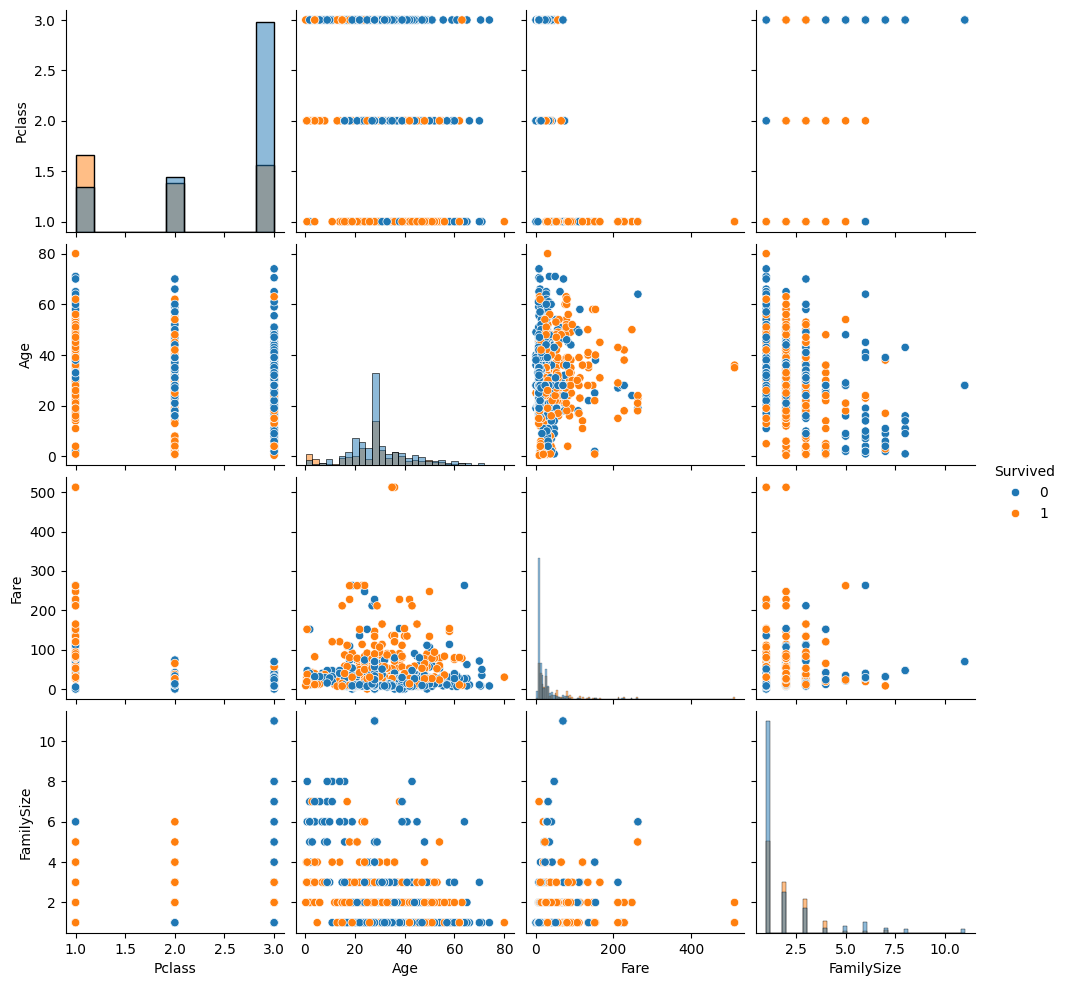

In [185]:
sns.pairplot(df[['Survived', 'Pclass', 'Age', 'Fare', 'FamilySize']], hue='Survived', diag_kind='hist')
plt.show()

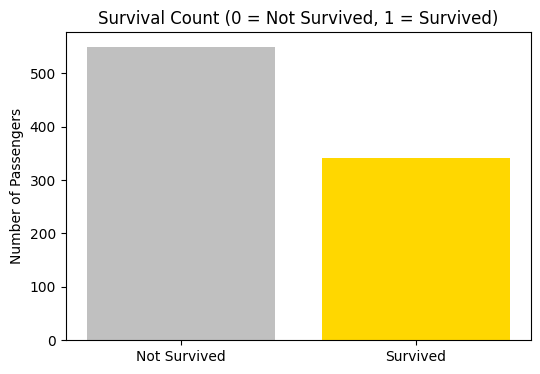

In [186]:
survived_counts = df['Survived'].value_counts()
plt.figure(figsize=(6,4))
plt.bar(['Not Survived', 'Survived'], survived_counts, color=['silver', 'gold'])
plt.title('Survival Count (0 = Not Survived, 1 = Survived)')
plt.ylabel('Number of Passengers')
plt.show()

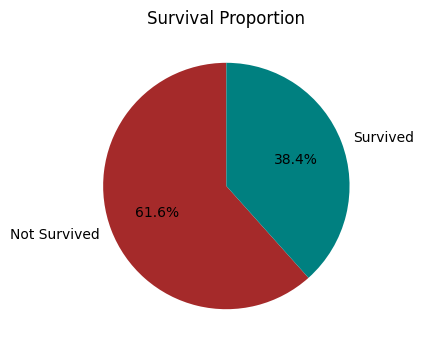

In [187]:
plt.figure(figsize=(4,4))
plt.pie(survived_counts, labels=['Not Survived', 'Survived'], autopct='%1.1f%%', colors=['brown','teal'], startangle=90)
plt.title('Survival Proportion')
plt.show()

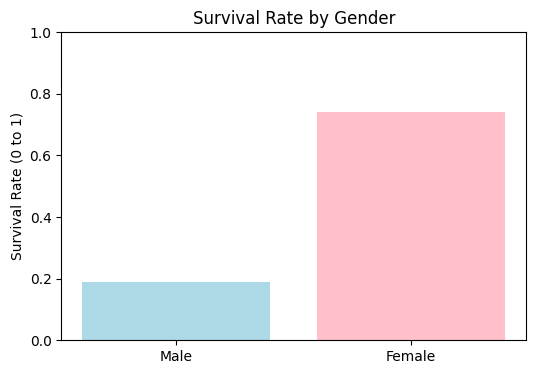

In [188]:
sex_survival = df.groupby('Sex')['Survived'].mean()
plt.figure(figsize=(6,4))
plt.bar(['Male', 'Female'], sex_survival, color=['lightblue', 'pink'])
plt.title('Survival Rate by Gender')
plt.ylabel('Survival Rate (0 to 1)')
plt.ylim(0, 1)
plt.show()

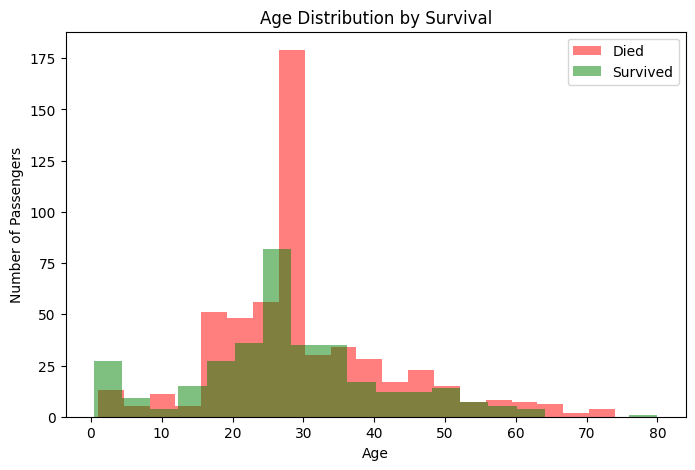

In [189]:
plt.figure(figsize=(8,5))
plt.hist(df[df['Survived']==0]['Age'], bins=20, alpha=0.5, label='Died', color='red', histtype='stepfilled')
plt.hist(df[df['Survived']==1]['Age'], bins=20, alpha=0.5, label='Survived', color='green', histtype='stepfilled')
plt.title('Age Distribution by Survival')
plt.xlabel('Age')
plt.ylabel('Number of Passengers')
plt.legend()
plt.show()

In [202]:
df['AgeGroup'] = df['AgeGroup'].map({'Child':0, 'Teen':1, 'Adult':2, 'Senior':3})

In [203]:
X = df.drop('Survived', axis=1)

In [204]:
y = df['Survived']

In [205]:
print("Features (X) shape:", X.shape)

Features (X) shape: (891, 9)


In [206]:
print("Target (y) shape:", y.shape)

Target (y) shape: (891,)


In [207]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [208]:
X_train

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,AgeGroup
331,1,0,45.5,0,0,28.5000,0,1,2
733,2,0,23.0,0,0,13.0000,0,1,2
382,3,0,32.0,0,0,7.9250,0,1,2
704,3,0,26.0,1,0,7.8542,0,2,2
813,3,1,6.0,4,2,31.2750,0,7,0
...,...,...,...,...,...,...,...,...,...
106,3,1,21.0,0,0,7.6500,0,1,2
270,1,0,28.0,0,0,31.0000,0,1,2
860,3,0,41.0,2,0,14.1083,0,3,2
435,1,1,14.0,1,2,120.0000,0,4,1


In [209]:
y_train

331    0
733    0
382    0
704    0
813    0
      ..
106    1
270    0
860    0
435    1
102    0
Name: Survived, Length: 712, dtype: int64

In [210]:
X_test

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,AgeGroup
709,3,0,28.0,1,1,15.2458,1,3,2
439,2,0,31.0,0,0,10.5000,0,1,2
840,3,0,20.0,0,0,7.9250,0,1,2
720,2,1,6.0,0,1,33.0000,0,2,0
39,3,1,14.0,1,0,11.2417,1,2,1
...,...,...,...,...,...,...,...,...,...
433,3,0,17.0,0,0,7.1250,0,1,1
773,3,0,28.0,0,0,7.2250,1,1,2
25,3,1,38.0,1,5,31.3875,0,7,2
84,2,1,17.0,0,0,10.5000,0,1,1


In [211]:
y_test

709    1
439    0
840    0
720    1
39     1
      ..
433    0
773    0
25     1
84     1
10     1
Name: Survived, Length: 179, dtype: int64

In [212]:
X_train.shape[0]

712

In [213]:
X_test.shape[0]

179

In [214]:
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [215]:
y_pred_lr = logreg.predict(X_test)

In [216]:
acc_lr = accuracy_score(y_test, y_pred_lr)

In [217]:
dtree = DecisionTreeClassifier(max_depth=4, random_state=42)
dtree.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=4, random_state=42)

In [218]:
y_pred_dt = dtree.predict(X_test)

In [219]:
acc_dt = accuracy_score(y_test, y_pred_dt)

In [220]:
print("Logistic Regression: " ,acc_lr, acc_lr*100)
print("Decision Tree:"       ,acc_dt, acc_dt*100)


Logistic Regression:  0.7821229050279329 78.2122905027933
Decision Tree: 0.7988826815642458 79.88826815642457


In [221]:
cm = confusion_matrix(y_test, y_pred_lr)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[88 17]
 [22 52]]


In [222]:
cm = confusion_matrix(y_test, y_pred_dt)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[96  9]
 [27 47]]


In [223]:
print(classification_report(y_test, y_pred_lr, target_names=['Died','Survived']))

              precision    recall  f1-score   support

        Died       0.80      0.84      0.82       105
    Survived       0.75      0.70      0.73        74

    accuracy                           0.78       179
   macro avg       0.78      0.77      0.77       179
weighted avg       0.78      0.78      0.78       179



In [224]:
print(classification_report(y_test, y_pred_dt, target_names=['Died','Survived']))


              precision    recall  f1-score   support

        Died       0.78      0.91      0.84       105
    Survived       0.84      0.64      0.72        74

    accuracy                           0.80       179
   macro avg       0.81      0.77      0.78       179
weighted avg       0.80      0.80      0.79       179



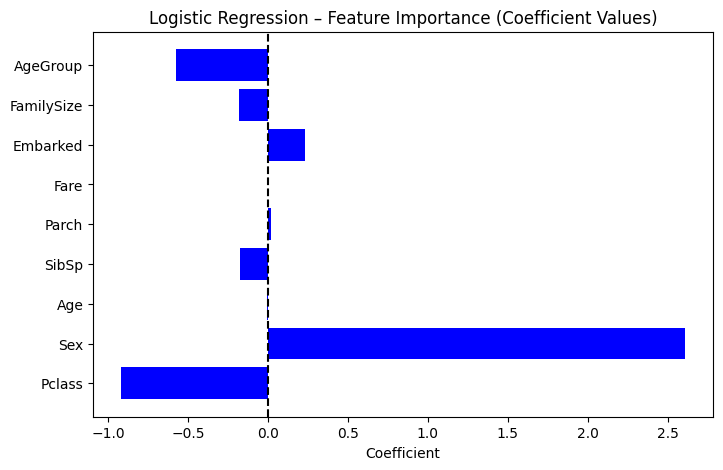

In [225]:
# Plot the coefficients of Logistic Regression
coeffs = logreg.coef_[0]
features = X.columns

plt.figure(figsize=(8,5))
plt.barh(features, coeffs, color='blue')
plt.title('Logistic Regression – Feature Importance (Coefficient Values)')
plt.xlabel('Coefficient')
plt.axvline(x=0, color='black', linestyle='--')
plt.show()

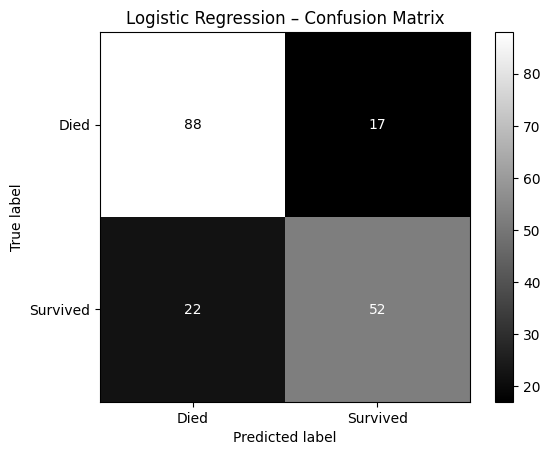

In [226]:
# Confusion matrix for Logistic Regression
cm_lr = confusion_matrix(y_test, y_pred_lr)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=['Died', 'Survived'])
disp_lr.plot(cmap='gray')
plt.title('Logistic Regression – Confusion Matrix')
plt.show()

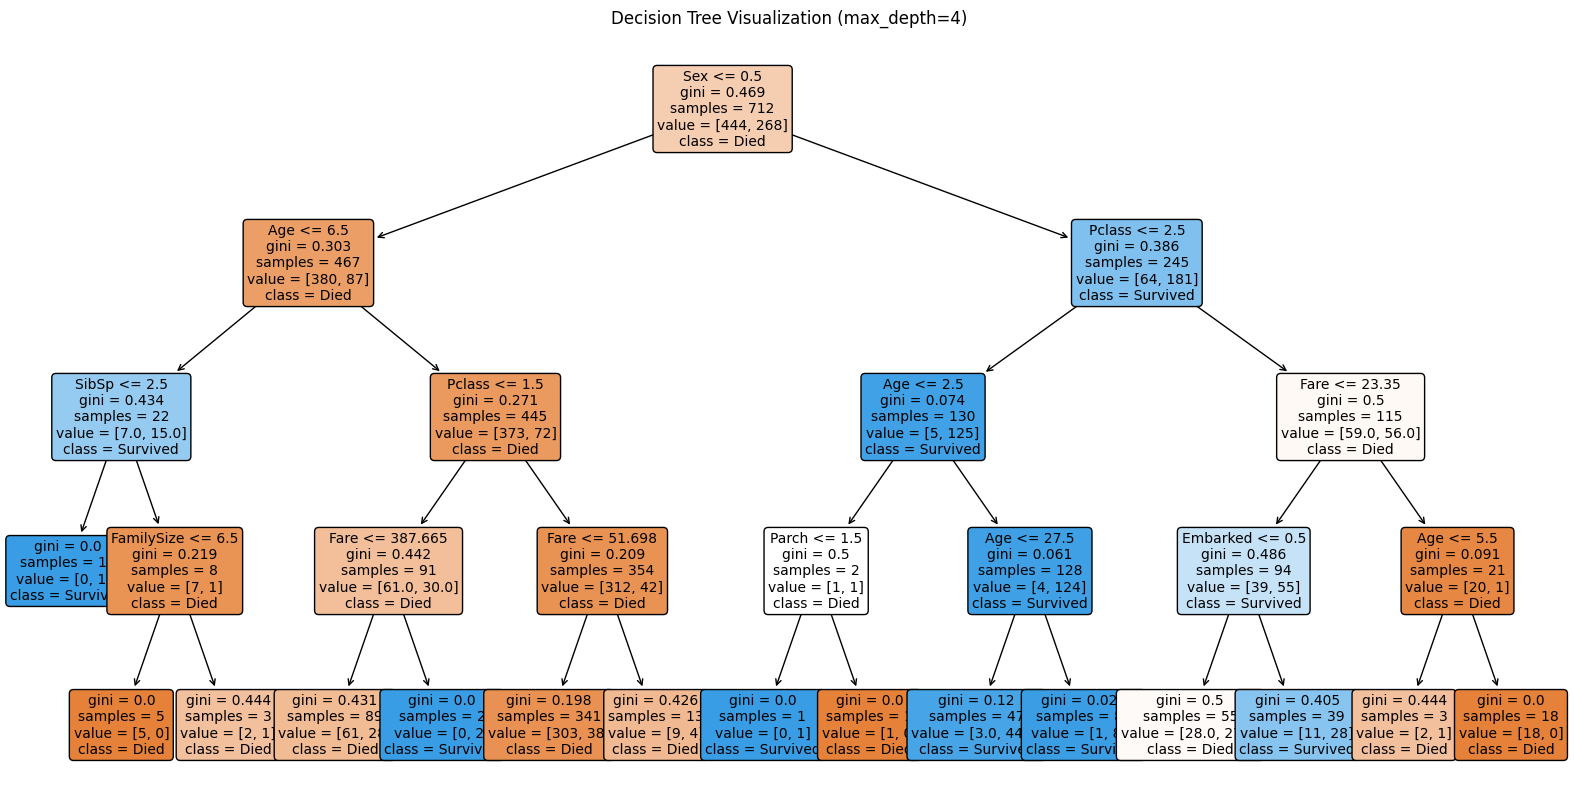

In [227]:
# Plot the decision tree structure
plt.figure(figsize=(20,10))
plot_tree(dtree, feature_names=X.columns, class_names=['Died', 'Survived'], filled=True, rounded=True, fontsize=10)
plt.title('Decision Tree Visualization (max_depth=4)')
plt.show()

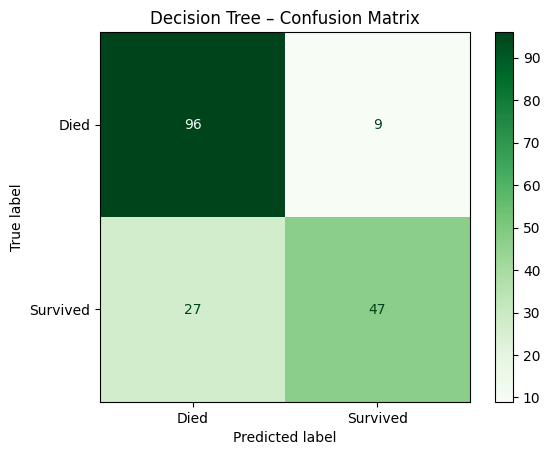

In [228]:
# Confusion matrix for Decision Tree
cm_dt = confusion_matrix(y_test, y_pred_dt)
disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=['Died', 'Survived'])
disp_dt.plot(cmap='Greens')
plt.title('Decision Tree – Confusion Matrix')
plt.show()

In [229]:
print("\nConfusion Matrix - Logistic Regression")
print(confusion_matrix(y_test, y_pred_lr))



Confusion Matrix - Logistic Regression
[[88 17]
 [22 52]]


In [230]:
print("\nConfusion Matrix - Decision Tree")
print(confusion_matrix(y_test, y_pred_dt))


Confusion Matrix - Decision Tree
[[96  9]
 [27 47]]


In [ ]:
coef = model.coef_[0]
features = X.columns
plt.figure()
sns.barplot(x=coef, y=features, palette='viridis')
plt.title('Feature Importance (Logistic Regression Coefficients)')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.axvline(x=0, color='red', linestyle='--')
plt.show()

new_passenger = [[1, 1, 28, 0, 0, 80]]  
prediction = model.predict(new_passenger)
probability = model.predict_proba(new_passenger)[0][1]

print("\n New Passenger Prediction:")
print(f" - Passenger: 1st class, Female, 28 years, Fare $80")
print(f" - Predicted Survival: {'SURVIVED' if prediction[0] == 1 else 'DIED'}")
print(f" - Probability of survival: {probability:.2f} ({probability*100:.2f}%)")



: 